# EDA — BRFSS Heart Disease (lifestyle, USA)

Analyse exploratoire du dataset BRFSS 2015 : distribution de la cible, association entre chaque
facteur déclaratif et la cardiopathie (tests du Chi²), effet de l'âge et de l'IMC, corrélations.

Cible : `HeartDiseaseorAttack` (0 = sain, 1 = cardiopathie ou infarctus).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, mannwhitneyu

from src.data_preprocessing import load_dataset

sns.set_style("whitegrid")
TARGET = "HeartDiseaseorAttack"


In [2]:
df = load_dataset('../../data/processed/heart_disease.csv', sep=',')
print(df.shape)
df.head()

(229781, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 1. Distribution de la cible

Point clé de ce dataset : le **déséquilibre des classes**. Contrairement au Cardio Train (50/50),
seuls ~10% des répondants déclarent une cardiopathie — c'est la réalité d'une enquête
populationnelle, et cela conditionnera la modélisation (voir `03_modeling.ipynb`).

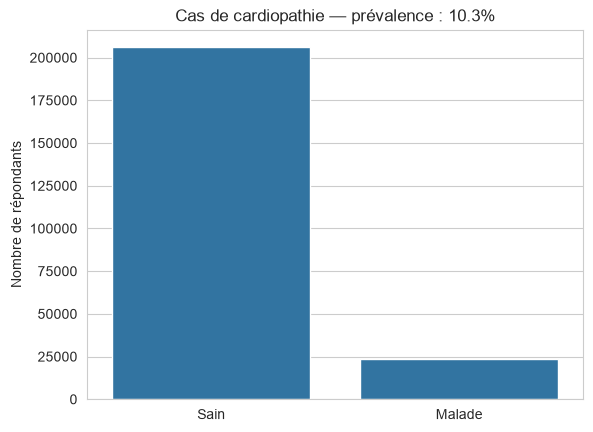

HeartDiseaseorAttack
0.0    206064
1.0     23717
Name: count, dtype: int64


In [3]:
counts = df[TARGET].value_counts()
prevalence = df[TARGET].mean()

sns.countplot(data=df, x=TARGET)
plt.xticks([0, 1], ["Sain", "Malade"])
plt.ylabel("Nombre de répondants")
plt.xlabel("")
plt.title(f"Cas de cardiopathie — prévalence : {prevalence:.1%}")
plt.show()

print(counts)

## 2. Risque par facteur déclaratif

Pour chaque facteur binaire, on compare le taux de cardiopathie entre les deux groupes et on teste
la significativité de l'association avec un **test du Chi²**.

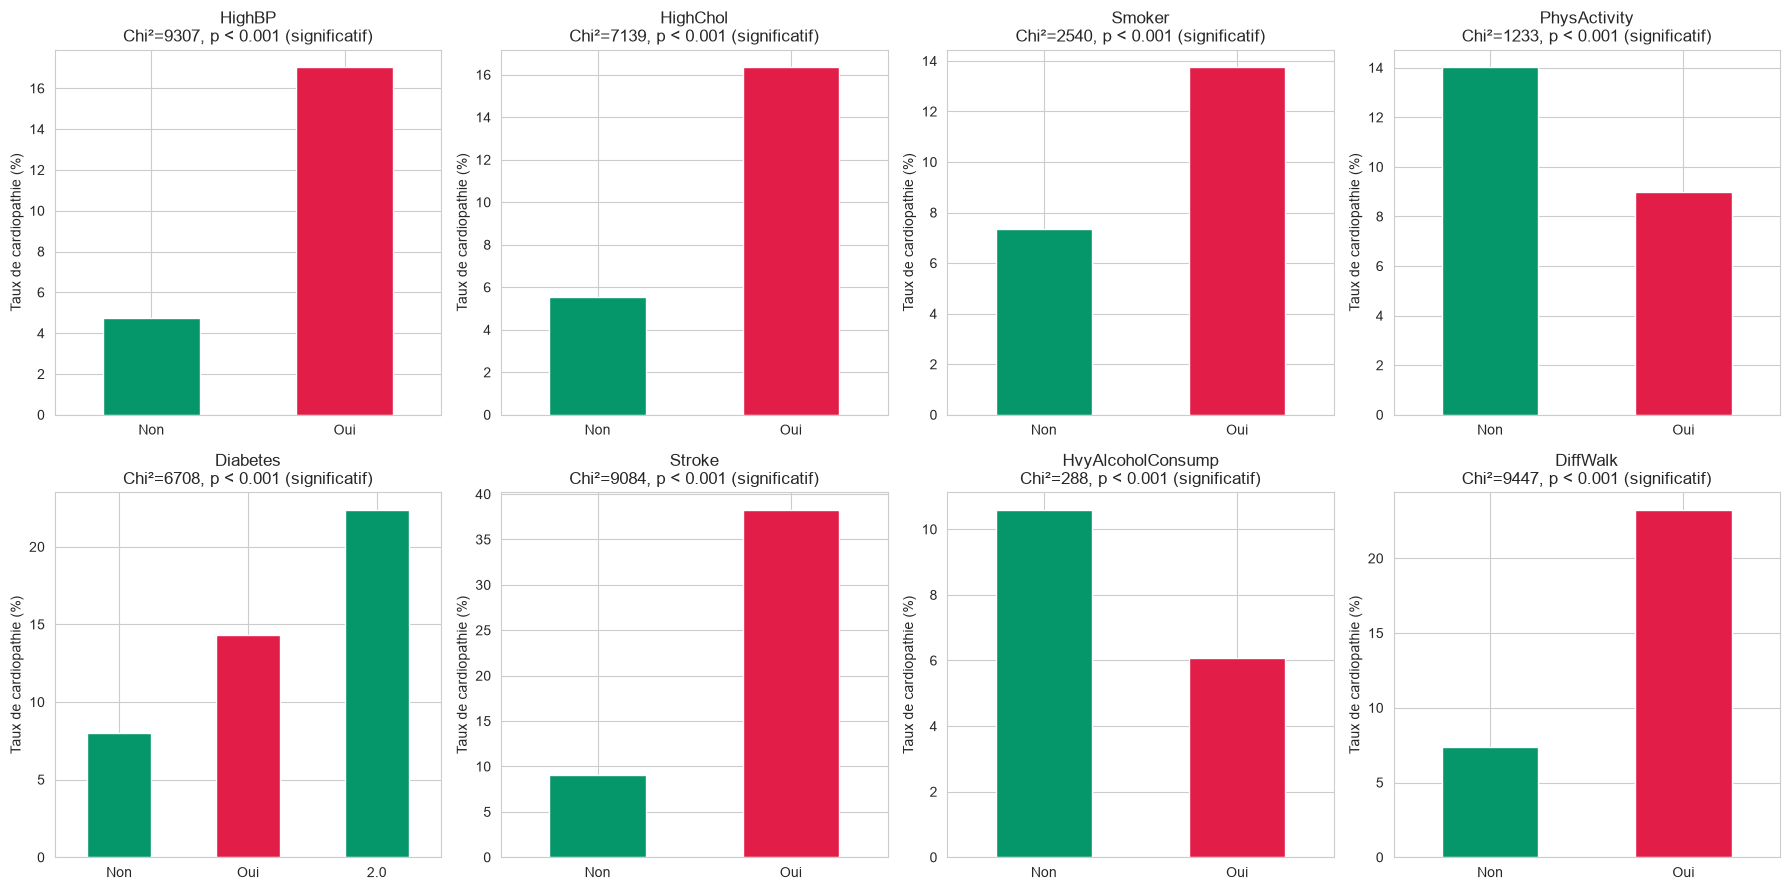

In [4]:
def analyse_facteur(df, variable, labels, ax):
    risk = df.groupby(variable)[TARGET].mean().mul(100)
    risk.index = [labels.get(i, i) for i in risk.index]
    risk.plot.bar(ax=ax, color=["#059669", "#e11d48"], rot=0)
    table = pd.crosstab(df[variable], df[TARGET])
    chi2, p, _, _ = chi2_contingency(table)
    sig = "significatif" if p < 0.05 else "non significatif"
    p_txt = "< 0.001" if p < 0.001 else f"{p:.3f}"
    ax.set_title(f"{variable}\nChi²={chi2:.0f}, p {p_txt} ({sig})")
    ax.set_ylabel("Taux de cardiopathie (%)")
    ax.set_xlabel("")

YN = {0.0: "Non", 1.0: "Oui"}
facteurs = ["HighBP", "HighChol", "Smoker", "PhysActivity", "Diabetes", "Stroke", "HvyAlcoholConsump", "DiffWalk"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for var, ax in zip(facteurs, axes.flat):
    analyse_facteur(df, var, YN, ax)
plt.tight_layout()
plt.show()

Tous les facteurs testés sont **statistiquement associés** à la cardiopathie (p < 0.001 — attendu
vu la taille de l'échantillon, 230k répondants). Les écarts les plus marqués : antécédent d'**AVC**,
**difficulté à marcher**, **hypertension** et **diabète**. À noter le sens contre-intuitif de
l'alcool excessif (taux plus bas chez les consommateurs), un artefact déclaratif connu de ce
dataset.

## 3. Risque par groupe d'âge

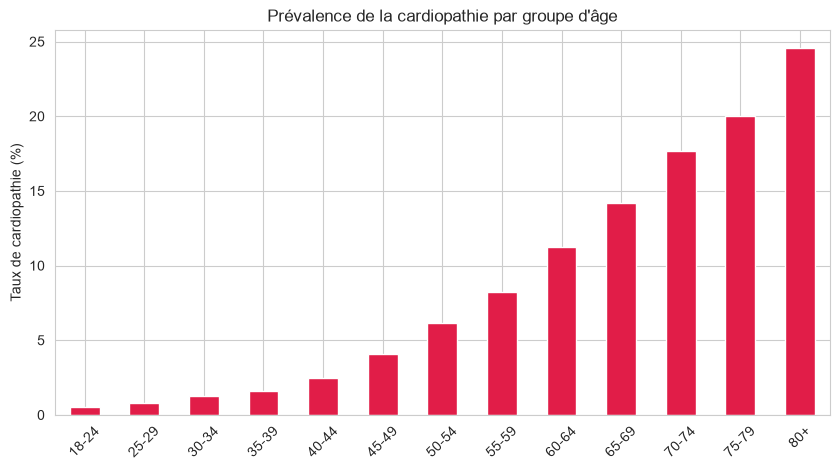

Chi² = 12397, p-value < 0.001


In [5]:
AGE_MAP = {
    1.0: "18-24", 2.0: "25-29", 3.0: "30-34", 4.0: "35-39",
    5.0: "40-44", 6.0: "45-49", 7.0: "50-54", 8.0: "55-59",
    9.0: "60-64", 10.0: "65-69", 11.0: "70-74", 12.0: "75-79", 13.0: "80+"
}

age_risk = df.groupby("Age")[TARGET].mean().mul(100)
age_risk.index = [AGE_MAP[i] for i in age_risk.index]

age_risk.plot.bar(figsize=(10, 5), color="#e11d48", rot=45)
plt.ylabel("Taux de cardiopathie (%)")
plt.title("Prévalence de la cardiopathie par groupe d'âge")
plt.show()

chi2, p, _, _ = chi2_contingency(pd.crosstab(df["Age"], df[TARGET]))
print(f"Chi² = {chi2:.0f}, p-value {'< 0.001' if p < 0.001 else round(p,3)}")

La progression est quasi exponentielle : de <1% avant 30 ans à ~20% après 80 ans. L'âge sera
logiquement l'un des premiers facteurs prédictifs du modèle.

## 4. IMC selon le statut (variable continue → test de Mann-Whitney)

/var/folders/mq/qk11kxq17fg1l6nqql63z_hm0000gn/T/ipykernel_70699/4037395783.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=TARGET, y="BMI", showfliers=False, palette=["#059669", "#e11d48"])


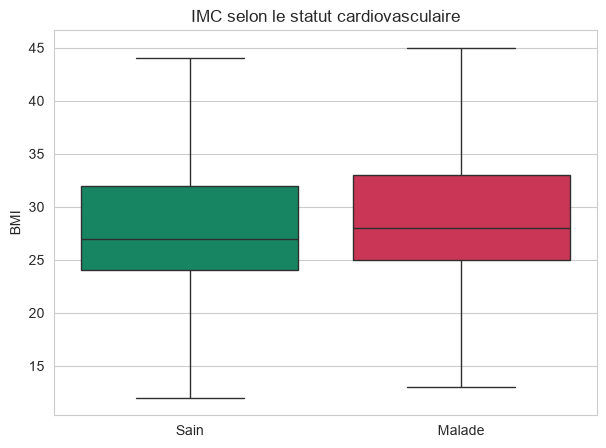

IMC moyen — sain : 28.6 | malade : 29.5
Mann-Whitney p-value < 0.001 → différence significative


In [6]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x=TARGET, y="BMI", showfliers=False, palette=["#059669", "#e11d48"])
plt.xticks([0, 1], ["Sain", "Malade"])
plt.xlabel("")
plt.title("IMC selon le statut cardiovasculaire")
plt.show()

g0 = df[df[TARGET] == 0]["BMI"]
g1 = df[df[TARGET] == 1]["BMI"]
stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
print(f"IMC moyen — sain : {g0.mean():.1f} | malade : {g1.mean():.1f}")
print(f"Mann-Whitney p-value {'< 0.001' if p < 0.001 else round(p, 3)} → différence significative")

## 5. Corrélations avec la cible

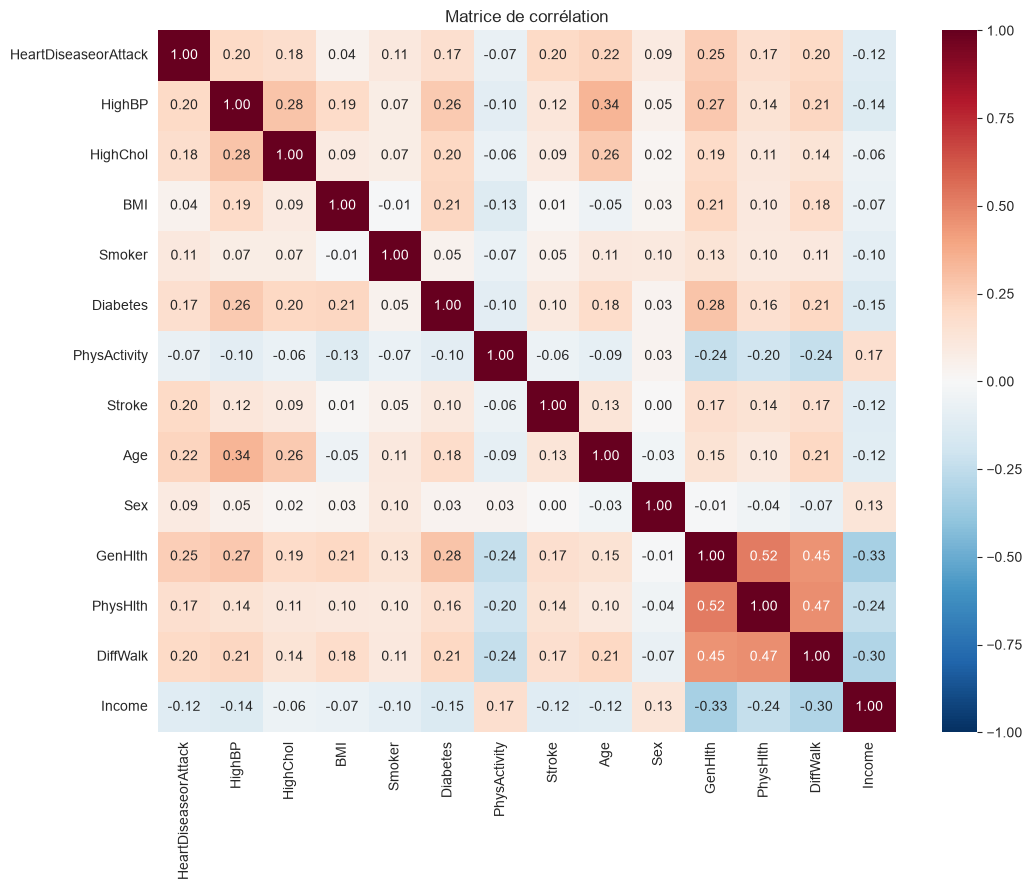

GenHlth         0.246
Age             0.224
DiffWalk        0.203
HighBP          0.201
Stroke          0.199
HighChol        0.176
Diabetes        0.171
PhysHlth        0.170
Income         -0.123
Smoker          0.105
Sex             0.090
PhysActivity   -0.073
BMI             0.040
Name: HeartDiseaseorAttack, dtype: float64

In [7]:
corr_cols = [TARGET, "HighBP", "HighChol", "BMI", "Smoker", "Diabetes",
             "PhysActivity", "Stroke", "Age", "Sex", "GenHlth", "PhysHlth", "DiffWalk", "Income"]
corr = df[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3)

## Conclusion de l'EDA

- La cible est **fortement déséquilibrée** (~10%) → pondération des classes et ROC-AUC en modélisation.
- Les corrélations individuelles avec la cible sont **modestes** (max ~0.23 pour l'âge et la santé
  générale perçue) : aucun facteur ne suffit seul, c'est leur combinaison qui portera le pouvoir
  prédictif — argument pour des modèles capables de capter les interactions (arbres, boosting).
- L'âge, la santé perçue (`GenHlth`), l'hypertension et le diabète ressortent comme les
  associations les plus nettes ; le gradient socio-économique (`Income`) est également visible.
- Validation de **H1** (habitudes de vie et indicateurs déclaratifs associés au risque) sur ce
  dataset ; la suite en modélisation dans `03_modeling.ipynb`.